# Alternative ELFI configurations

Alternative ELFI model: nodes separately for SIR and BSI

In [5]:
import elfi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import graphviz # conda install python-graphviz

In [6]:
from cluster.scripts.load_data import *
or_data.head()

,Collection,Clade,Label,carriage_nonPP,Disease_nonPP,carriage_PP,Disease_PP,OR,lower,upper,pval_f<=5_chi>5,p.adj BH
0,NORM,A,A (NORM),387,3179,16,75,0.5706,0.3292,0.9890,0.0429,0.1287
1,BSAC,A,A (BSAC),387,1490,16,19,0.3084,0.1571,0.6054,0.0003,0.0018
2,Combined,A,A (Combined),387,4669,16,94,0.4870,0.2837,0.8357,0.0077,0.0308
3,NORM,B,B (NORM),389,3172,14,82,0.7183,0.4036,1.2784,0.2585,0.3878
4,BSAC,B,B (BSAC),389,1464,14,45,0.8541,0.4640,1.5721,0.6120,0.6303


In [25]:
import importlib
import cluster.scripts.BSI_functions
import cluster.scripts.SIR_functions

importlib.reload(cluster.scripts.BSI_functions) # for changes in the file to take effect
importlib.reload(cluster.scripts.SIR_functions)

from cluster.scripts.BSI_functions import *
from cluster.scripts.SIR_functions import prop_to_nSIR, SIR

In [26]:
# Specifying data-related parameters:

bsi_obs_data = get_obs_BSI(df = norm_data, clade = "A", is_prop = True)
print(bsi_obs_data)

n_years = max(bsi_obs_data.index) - min(bsi_obs_data.index) # years of interest
n_weeks = (n_years + 1)*52 # weeks of interest
print(f'Number of weeks to simulate: {n_weeks}')

pop_size = 100000
print(f'Population size: {pop_size}')


2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64
Number of weeks to simulate: 832
Population size: 100000


In [27]:
def BSI_max_t(y):
    # time to peak/maximum number of bsi cases
    
    return np.argmax(y, axis = 1, keepdims=True)

def BSI_max(y):
    # maximum number of BSI cases
    
    max_bsi = np.max(y[:,], axis = 1, keepdims=True)
    
    return max_bsi#.reshape(-1,1).transpose()

(1, 16)
(1, 2)


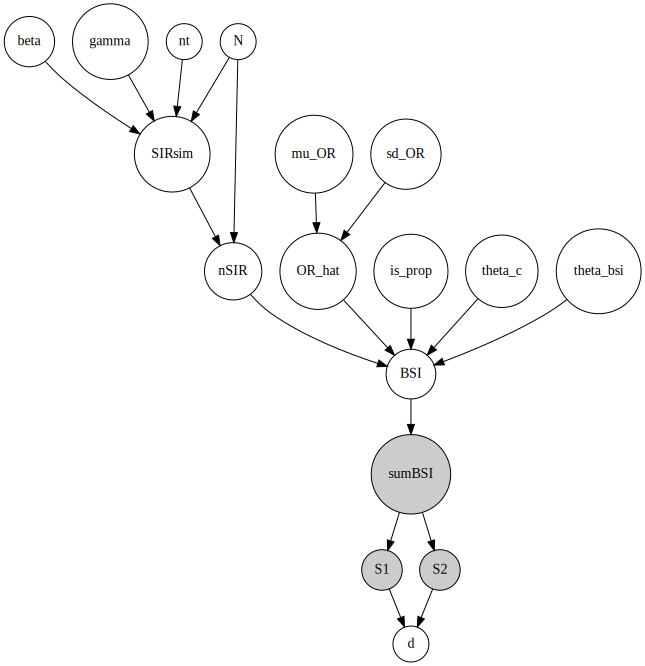

In [33]:
# Elfi model with SIR and obs model in separate nodes

elfi.new_model()
elfi.set_client('native') # parallellization

bs = 10

SIR_obs = prop_to_nSIR(SIR(np.array(0.734), np.array(1/30), nt = n_weeks, N = pop_size, batch_size = 1), pop_size)
OR_hat = get_OR_hat(or_data, clade = "A", dataset = "NORM")
bsi_obs = sum_over_bsi(col_to_BSI(SIR_obs, OR_hat = OR_hat, is_prop = False))#.flatten()
print(bsi_obs.shape)

obsS1 = BSI_max_t(bsi_obs)
obsS2 = BSI_max(bsi_obs)
obs_summaries = (obsS1, obsS2)

mu_OR, sd_OR = get_OR_hat_pars(or_data, clade = "A", dataset = "NORM")

bsi_parameters = {"or_data": or_data, "clade":"A", "dataset":"NORM", "theta_c":1, "theta_bsi":0.3} # todo: deprecate this

# Clancy et al: uninformative gamma priors for beta and gamma
beta = elfi.Prior(scipy.stats.gamma,1,0, 0.1)
gamma = elfi.Prior(scipy.stats.gamma,1,0, 0.1)

nt = elfi.Constant(n_weeks)
N = elfi.Constant(pop_size)

mu_OR = elfi.Constant(mu_OR)
sd_OR = elfi.Constant(sd_OR)
OR_hat = elfi.RandomVariable(scipy.stats.norm, mu_OR, sd_OR)

print(np.array([obsS1, obsS2]).reshape(-1,1).transpose().shape)

# This node outputs SIR simulations, but the observed data is BSI.

SIRsim = elfi.Operation(SIR, beta, gamma, nt, N) # PROBLEM: The observations do not match this node. 

# SIRsim = elfi.Simulator(SIR, beta, gamma, nt, N, observed = bsi_obs) # PROBLEM: The observations do not match this node. 

nSIR = elfi.Operation(prop_to_nSIR, SIRsim, N)

is_prop = elfi.Constant(False)

theta_c = elfi.Constant(1)
theta_bsi = elfi.Constant(0.28)
BSI = elfi.Operation(col_to_BSI, nSIR, OR_hat, theta_c, theta_bsi, is_prop)

# sumBSI = elfi.Operation(sum_over_bsi, BSI) # is there any way of inputting observed data to this node?

sumBSI = elfi.Simulator(sum_over_bsi, BSI, observed=bsi_obs) # is there any way of inputting observed data to this node?


S1 = elfi.Summary(BSI_max_t, sumBSI)
S2 = elfi.Summary(BSI_max, sumBSI)


#d = elfi.Discrepancy(euclidean_distance, S1, S2, obs_summaries)

d = elfi.Distance('euclidean', S1, S2)

elfi.draw(d)

In [34]:
S1.generate(1)

(1,)

In [35]:
S2.generate(3).shape

(3, 1)

In [36]:
d.generate(3)

array([182548.4993258 , 313210.71735773, 411758.19262775])

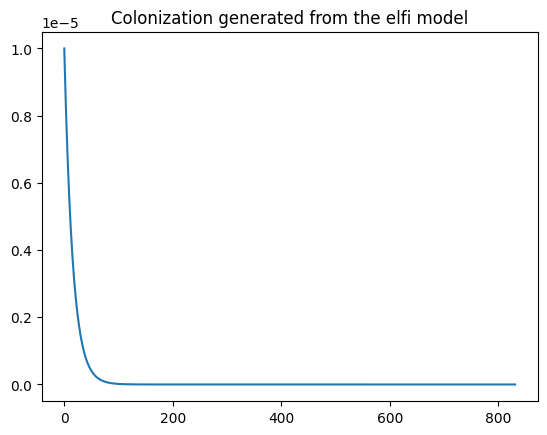

In [9]:
plt.plot(SIRsim.generate(1)[1][0])
plt.title("Colonization generated from the elfi model")
plt.show()

In [10]:
rej = elfi.Rejection(d)
rej.sample(10, quantile=0.01)

Progress [==================================================] 100.0% Complete


Method: Rejection
Number of samples: 10
Number of simulations: 1000
Threshold: 8.29e+03
Parameter                Mean               2.5%              97.5%
beta:                   0.152              0.024              0.344
gamma:                  0.025              0.006              0.044
